<a href="https://colab.research.google.com/github/mmeenakshibio2016-byte/studious-parakeet/blob/main/UnilensAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn xgboost shap sentence-transformers streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 74.4 MB/s eta 0:00:00


In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from xgboost import XGBClassifier


df = pd.read_csv("/content/THE World University Rankings 2016-2025.csv")

# Standardize column names: convert to lowercase, replace non-alphanumeric characters with underscores,
# replace multiple underscores with single, and strip leading/trailing underscores.
df.columns = df.columns.str.strip()\
                      .str.lower()\
                      .str.replace(r'[^a-z0-9_]+', '_', regex=True)\
                      .str.replace(r'_{2,}', '_', regex=True)\
                      .str.strip('_')

# Print actual column names to diagnose the KeyError
print("DataFrame columns after cleaning:", df.columns.tolist())

# Filter out countries with only one occurrence to avoid ValueError in train_test_split with stratify
country_counts = df['country'].value_counts()
single_occurrence_countries = country_counts[country_counts == 1].index
df = df[~df['country'].isin(single_occurrence_countries)]

features = [
    "rank",
    "overall_score",
    "teaching",
    "research_environment",
    "research_quality",
    "industry_impact",
    "international_outlook"
]


X = df[features]

y = df["country"]


encoder = LabelEncoder()

y = encoder.fit_transform(y)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)


model.fit(X_train, y_train)


predictions = model.predict(X_test)


print("Accuracy:",
      accuracy_score(y_test, predictions))

# Get the unique classes present in y_test
test_labels = np.unique(y_test)
# Map these labels back to their original country names for target_names
test_target_names = encoder.inverse_transform(test_labels)

print(
    classification_report(
        y_test,
        predictions,
        labels=test_labels,  # Specify the labels to consider
        target_names=test_target_names
    )
)

DataFrame columns after cleaning: ['rank', 'name', 'country', 'student_population', 'students_to_staff_ratio', 'international_students', 'female_to_male_ratio', 'overall_score', 'teaching', 'research_environment', 'research_quality', 'industry_impact', 'international_outlook', 'year']
Accuracy: 0.5137741046831956
                      precision    recall  f1-score   support

             Algeria       0.59      0.65      0.62        20
           Argentina       0.20      0.14      0.17         7
           Australia       0.58      0.62      0.60        72
             Austria       0.62      0.40      0.48        20
          Azerbaijan       0.00      0.00      0.00         1
          Bangladesh       0.25      0.12      0.17         8
             Belarus       0.50      0.50      0.50         2
             Belgium       0.70      0.41      0.52        17
            Botswana       0.00      0.00      0.00         1
              Brazil       0.48      0.43      0.46        90
  

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
display(df.head())

,rank,name,country,student_population,students_to_staff_ratio,international_students,female_to_male_ratio,overall_score,teaching,research_environment,research_quality,industry_impact,international_outlook,year
0,1.0,California Institute of Technology,United States,2243.0,6.9,26%,33 : 67,95.2,95.6,97.6,99.8,97.8,64.0,2016
1,2.0,University of Oxford,United Kingdom,19920.0,11.6,34%,46:54:00,94.2,86.5,98.9,98.8,73.1,94.4,2016
2,3.0,Stanford University,United States,15596.0,7.8,22%,42:58:00,93.9,92.5,96.2,99.9,63.3,76.3,2016
3,4.0,University of Cambridge,United Kingdom,18810.0,11.8,34%,46:54:00,92.8,88.2,96.7,97.0,55.0,91.5,2016
4,5.0,Massachusetts Institute of Technology,United States,11074.0,9.0,33%,37 : 63,92.0,89.4,88.6,99.7,95.4,84.0,2016


In [18]:
unique_countries = df['country'].unique()
display(unique_countries)

array(['United States', 'United Kingdom', 'Switzerland', 'Canada',
       'Singapore', 'Sweden', 'Germany', 'Australia', 'Belgium', 'China',
       'Japan', 'Hong Kong', 'Netherlands', 'France', 'Finland',
       'Denmark', 'South Korea', 'Ireland', 'Italy', 'South Africa',
       'Norway', 'Austria', 'Spain', 'Russian Federation', 'Taiwan',
       'New Zealand', 'Israel', 'Luxembourg', 'Brazil', 'Iceland',
       'Turkey', 'Saudi Arabia', 'India', 'Czech Republic', 'Greece',
       'Estonia', 'Cyprus', 'Portugal', 'Uganda', 'Chile', 'Macao',
       'Mexico', 'Iran', 'Malaysia', 'Lebanon', 'Poland', 'Hungary',
       'Thailand', 'Pakistan', 'Romania', 'Slovenia',
       'United Arab Emirates', 'Colombia', 'Qatar', 'Lithuania', 'Oman',
       'Ghana', 'Slovakia', 'Latvia', 'Serbia', 'Jordan', 'Egypt',
       'Kenya', 'Indonesia', 'Ukraine', 'Bangladesh', 'Belarus',
       'Morocco', 'Nigeria', 'Argentina', 'Kuwait', 'Northern Cyprus',
       'Croatia', 'Philippines', 'Costa Rica', 'Vene

In [23]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

embeddings = embedding_model.encode(
    df["name"].fillna("").tolist()
)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(14522, 384)


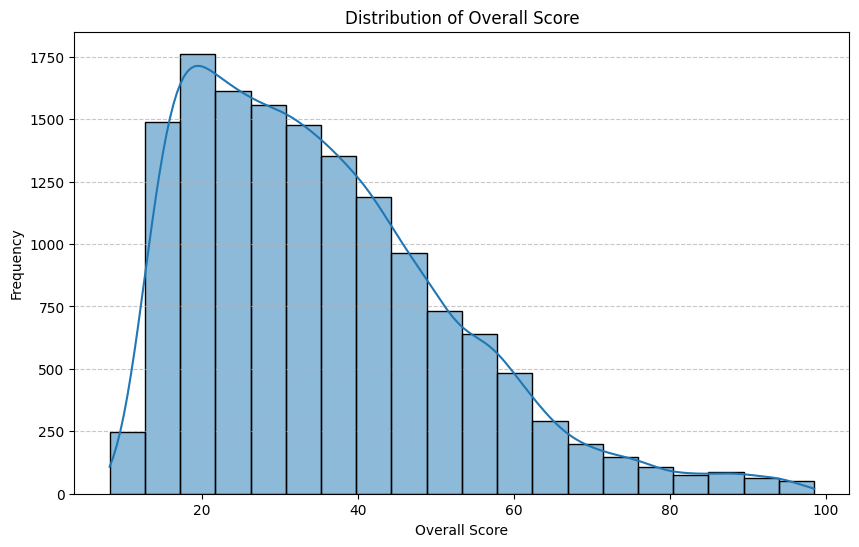

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['overall_score'], kde=True, bins=20)
plt.title('Distribution of Overall Score')
plt.xlabel('Overall Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model)

# explainer.shap_values for multi-class typically returns a list of arrays,
# where each array is (n_samples, n_features) for a specific class.
# To get an overall summary plot, we can average the absolute SHAP values across all classes.
shap_values = explainer.shap_values(X_test)

# Convert the list of 2D arrays to a 3D numpy array if it's a list,
# then calculate the mean of absolute SHAP values along the class axis (axis=0 for the stacked array).
if isinstance(shap_values, list):
    # Stack the list of (n_samples, n_features) arrays into a (n_classes, n_samples, n_features) array
    shap_values_stacked = np.array(shap_values)
    # Calculate the mean absolute SHAP values across classes (axis=0)
    mean_abs_shap_values = np.abs(shap_values_stacked).mean(axis=0)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # If shap_values is already a 3D array (n_samples, n_classes, n_features)
    # Calculate the mean absolute SHAP values across classes (axis=1)
    mean_abs_shap_values = np.abs(shap_values).mean(axis=1)
else:
    # For binary classification or regression, shap_values would be a 2D array
    mean_abs_shap_values = np.abs(shap_values)

shap.summary_plot(
    mean_abs_shap_values, # Pass the aggregated 2D SHAP values
    X_test,
    feature_names=features
)

In [ ]:
app.py